<a href="https://colab.research.google.com/github/Cicikuss/Learning-to-Build-Autonomous-Car/blob/main/Multiclass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from sklearn import datasets
import keras
from keras.models import Sequential
from keras.layers import Dense
from keras.optimizers import Adam
from keras.utils import to_categorical

In [ ]:
n_pts = 500
centers = [[-1,1],[-1,-1],[1,-1]]
X,y = datasets.make_blobs(n_samples=n_pts,random_state=123,centers=centers,cluster_std=0.4)


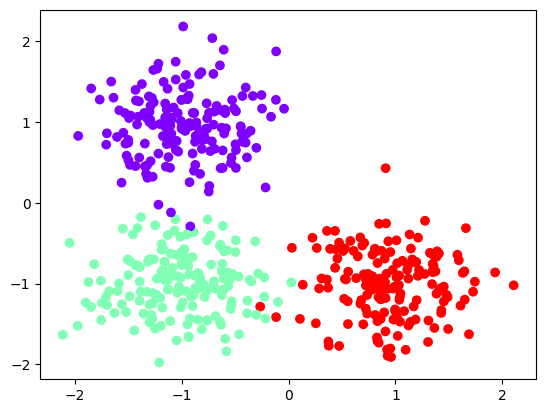

In [ ]:
plt.scatter(X[:,0],X[:,1],c=y,cmap='rainbow')

In [ ]:
y_cat = to_categorical(y,3)
print(y_cat)

[[0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 ...
 [0. 1. 0.]
 [0. 1. 0.]
 [1. 0. 0.]]


In [ ]:
model = Sequential()
model.add(Dense(units=3,input_shape=(2,),activation='softmax'))
model.compile(Adam(learning_rate=0.1),loss = 'categorical_crossentropy',metrics=['accuracy'])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
h=model.fit(x=X,y=y_cat,verbose=1,batch_size=50,epochs=100)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6060 - loss: 1.0062  
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9900 - loss: 0.2489 
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9900 - loss: 0.1228 
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9860 - loss: 0.0883 
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9860 - loss: 0.0752 
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0676 
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9880 - loss: 0.0631 
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9880 - loss: 0.0598 
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9860 - loss: 0.0575 
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9880 - loss: 0.0542 
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9880 - loss: 0.0523 
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step

In [ ]:
def plot_decision_boundry(X,y_cat,model):
  x_span = np.linspace(min(X[:,0])-1, max(X[:,0])+1, 50)
  y_span = np.linspace(min(X[:,1])-1, max(X[:,1])+1, 50)
  xx , yy = np.meshgrid(x_span , y_span)
  xx_ , yy_ = xx.ravel() , yy.ravel()
  grid = np.c_[xx_ , yy_]
  pred_func = model.predict(grid)
  z = np.argmax(pred_func,axis=1).reshape(xx.shape)
  plt.contourf(xx, yy, z)

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


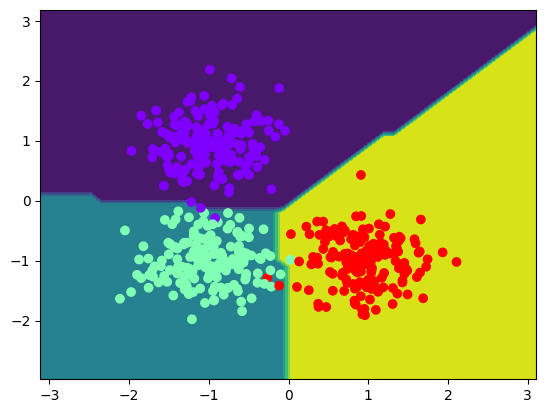

In [ ]:
plot_decision_boundry(X,y_cat,model)
plt.scatter(X[:,0],X[:,1],c=y,cmap='rainbow')

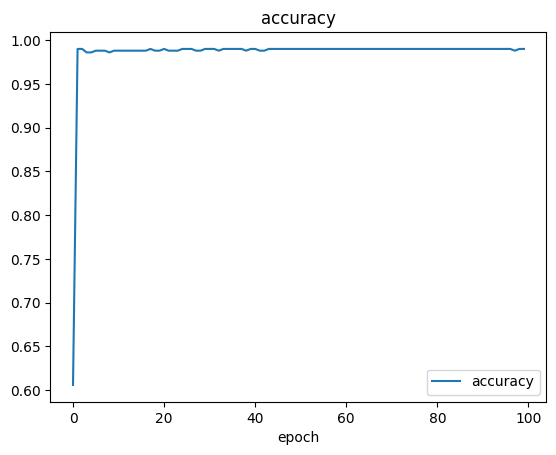

In [ ]:
plt.plot(h.history['accuracy'])
plt.title('accuracy')
plt.xlabel('epoch')
plt.legend(['accuracy'])

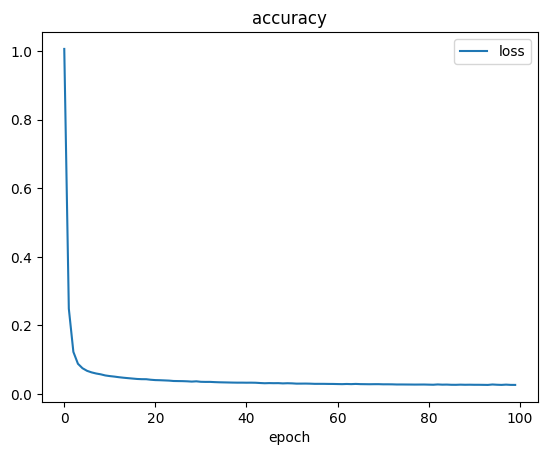

In [ ]:
plt.plot(h.history['loss'])
plt.title('accuracy')
plt.xlabel('epoch')
plt.legend(['loss'])

79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
prediction is  1


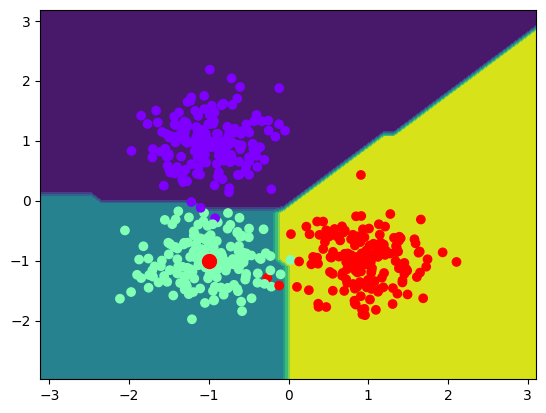

In [ ]:
plot_decision_boundry(X,y_cat,model)
plt.scatter(X[:,0],X[:,1],c=y,cmap='rainbow')
x=-1
y=-1
point = np.array([[x,y]])
prediction =model.predict(point)
prediction = np.argmax(prediction)
plt.plot([x],[y],marker='o',markersize=10,color='red')
print('prediction is ',prediction)